# Frame & Topic Analysis

### Imports/Data

In [78]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [79]:
#load data
full_df = pd.read_parquet('merged_topic_and_frames_filtered.parquet')

full_df.head()

,uuid,url,outlet_name,bias,date,content,content_preprocessed,topic_top1,topic_top1_score,topic_top2,topic_top2_score,topic_top3,topic_top3_score,frames,vector,probs,max_frame_prob,max_frame_idx,year_month
0,11362746988981500303,https://www.huffpost.com/entry/cancer-debunkin...,HuffPost,Left,2017-03-13,The term “integrative therapies” describes the...,The term “integrative therapies” describes the...,healthcare,0.981742,Russia,0.003445,Middle East,0.003432,"[health, policy, quality_life]","[0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0]","[0.0067, 0.29751, 0.02502, 0.06441, 0.212, 0.9...",0.99998,5,2017-03
1,2813003261424375394,https://www.huffpost.com/archive/ca/entry/mich...,HuffPost,Left,2015-02-10,"AMC\nFor Canadian actor Michael Mando, lightni...","AMC\nFor Canadian actor Michael Mando, lightni...",entertainment,0.900575,crime,0.039743,immigration,0.021471,"[crime, culture, quality_life]","[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]","[0.00012, 0.97306, 0.97458, 0.00209, 0.02459, ...",0.99987,11,2015-02
2,13243574870888809612,https://www.huffpost.com/entry/walking-dead-se...,HuffPost,Left,2019-07-19,"SAN DIEGO ― Heading into Season 10, the only t...","SAN DIEGO ― Heading into Season 10, the only t...",entertainment,0.765275,pandemic,0.226657,Middle East,0.001457,"[policy, public_op, quality_life, security]","[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1]","[7e-05, 0.60656, 0.39725, 0.00032, 0.00708, 0....",0.99838,10,2019-07
3,4340615711027464742,https://www.huffpost.com/entry/trump-military-...,HuffPost,Left,2017-01-19,WASHINGTON ― Part of being a great president i...,WASHINGTON ― Part of being a great president i...,elections and politics,0.865624,technology,0.070364,entertainment,0.013535,"[legality, policy, regulation, security]","[0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1]","[0.00083, 0.10453, 0.0409, 0.00408, 0.00716, 0...",0.99996,13,2017-01
4,15731527146425700041,https://www.huffpost.com/entry/coronavirus-sec...,HuffPost,Left,2020-06-17,"Across Europe and much of the United States, t...","Across Europe and much of the United States, t...",entertainment,0.708834,healthcare,0.120574,pandemic,0.073840,"[health, legality, policy, public_op, quality_...","[0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1]","[0.00732, 0.05876, 0.00636, 0.00273, 0.03956, ...",0.99893,5,2020-06


In [113]:
print(full_df['outlet_name'].value_counts())

outlet_name
Newsweek               21579
Breitbart News         14671
HuffPost                9617
New York Post           8424
CNBC                    7957
Reuters                 6979
Washington Times        6579
The Washington Post     2770
BBC News                2207
Name: count, dtype: int64


In [92]:
def group_bias(bias):
    if bias in ['Left', 'Lean Left']:
        return 'Left'
    elif bias in ['Right', 'Lean Right']:
        return 'Right'
    else:
        return 'Center'

full_df['bias_grouped'] = full_df['bias'].apply(group_bias)

print(full_df['bias_grouped'].value_counts())

left_df = full_df[full_df['bias_grouped'] == 'Left']
right_df = full_df[full_df['bias_grouped'] == 'Right']

bias_grouped
Left      33966
Right     29674
Center    17143
Name: count, dtype: int64


### Map Frames & Biases

In [80]:
# Find the mapping from vector positions to frame names
frame_mapping = {}

for idx, row in full_df.iterrows():
    frames = row['frames']
    vector = row['vector']
    
    # Convert arrays
    if isinstance(frames, np.ndarray):
        frames = frames.tolist()
    if isinstance(vector, np.ndarray):
        vector = vector.tolist()
    
    # Run through
    frame_idx = 0
    for i, val in enumerate(vector):
        if val == 1:
            frame_mapping[i] = frames[frame_idx]
            frame_idx += 1

# Get list and map
ordered_frame_names = [frame_mapping[i] for i in sorted(frame_mapping.keys())]

print(ordered_frame_names)
print(frame_mapping)

['cap&res', 'crime', 'culture', 'economic', 'fairness', 'health', 'legality', 'morality', 'policy', 'political', 'public_op', 'quality_life', 'regulation', 'security']
{5: 'health', 8: 'policy', 11: 'quality_life', 1: 'crime', 2: 'culture', 10: 'public_op', 13: 'security', 6: 'legality', 12: 'regulation', 0: 'cap&res', 3: 'economic', 4: 'fairness', 9: 'political', 7: 'morality'}


In [81]:
# Colors by party bias
color_map = {
    'Left':'#0015BC',           # Blue (Dem blue)
    'Lean Left': '#6BA3D3',      # Light blue
    'Center': '#808080',         # Grey
    'Lean Right': '#E8A1A1',     # Light red
    'Right': '#E81B23'           # Red (GOP red)
}

column_order = ['Left', 'Lean Left', 'Center', 'Lean Right', 'Right']

topic_list = full_df['topic_top1'].unique()

### Topics Over Time by Bias

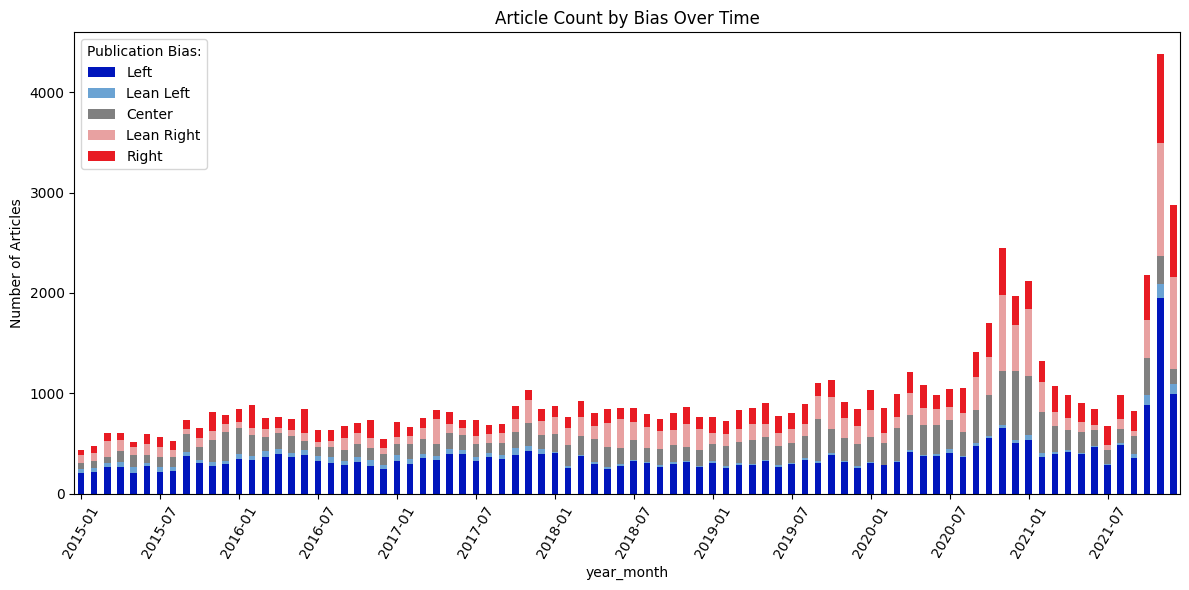

In [ ]:
# Count Summary by Bias
bias_counts = full_df.groupby(['year_month', 'bias']).size().unstack(fill_value=0)
bias_counts = bias_counts.reindex(columns=column_order, fill_value=0)

# Plot
bias_counts.plot(kind='bar', stacked=True, figsize=(12, 6), color=[color_map[bias] for bias in bias_counts.columns])

plt.ylabel('Number of Articles')
plt.title('Article Count by Bias Over Time')
plt.legend(title='Publication Bias:')
plt.xticks(range(0, len(bias_counts), 6), bias_counts.index[::6],rotation=60)
plt.tight_layout()
plt.show()

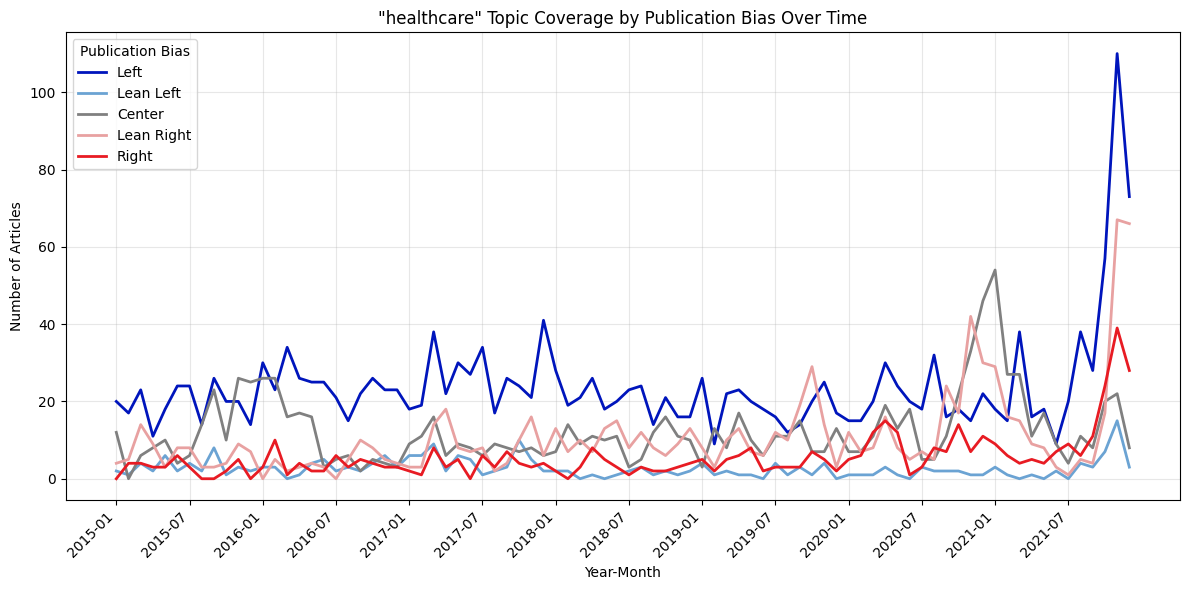

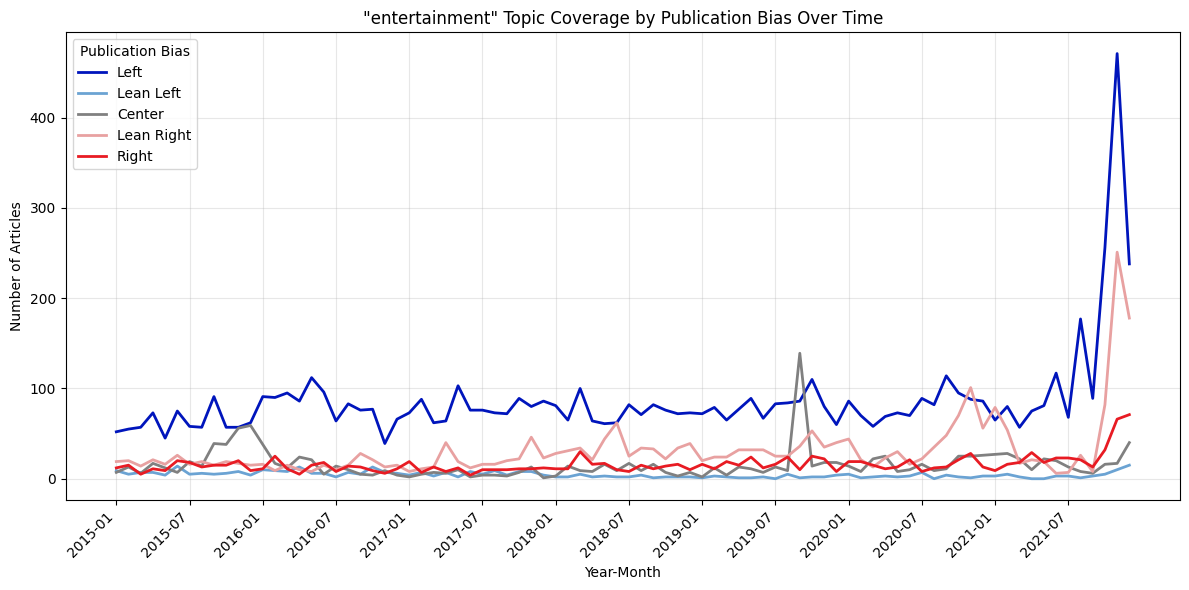

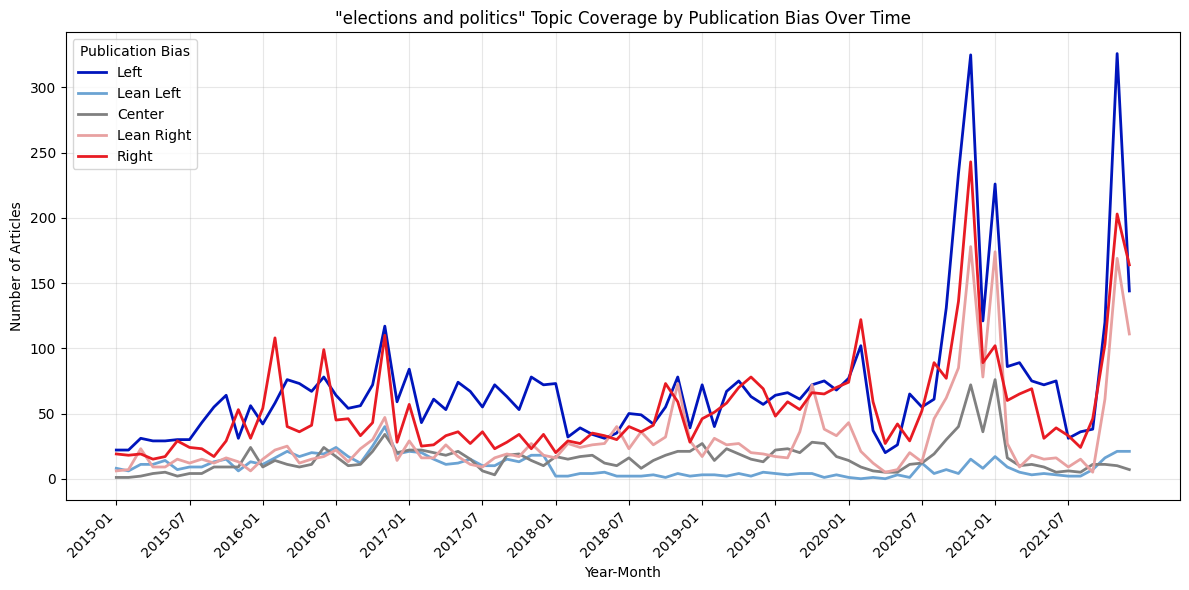

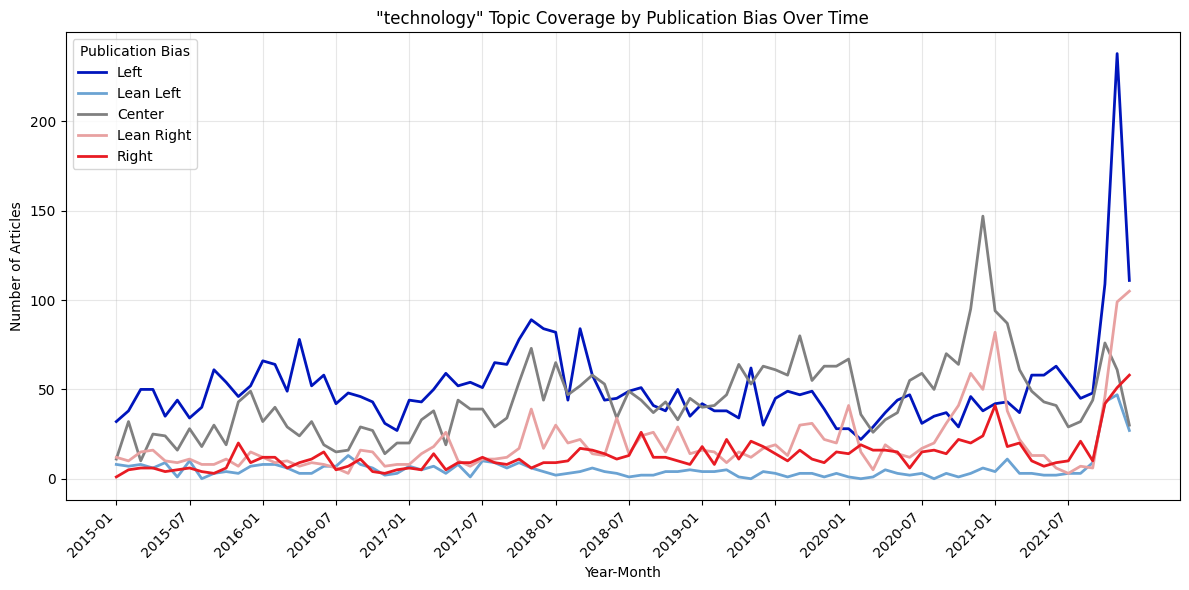

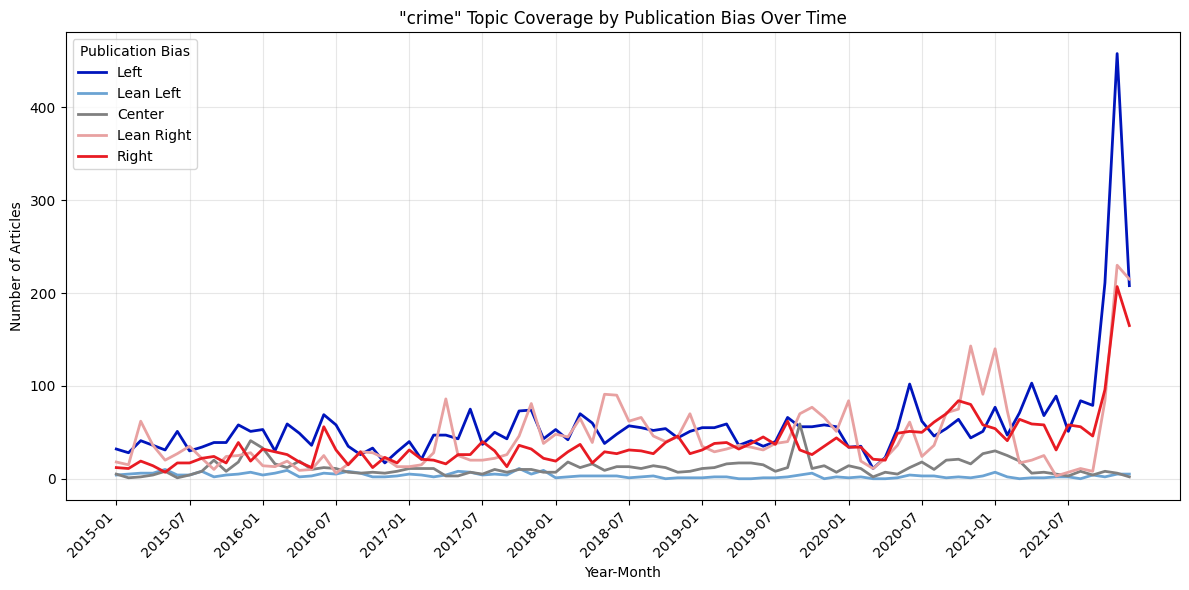

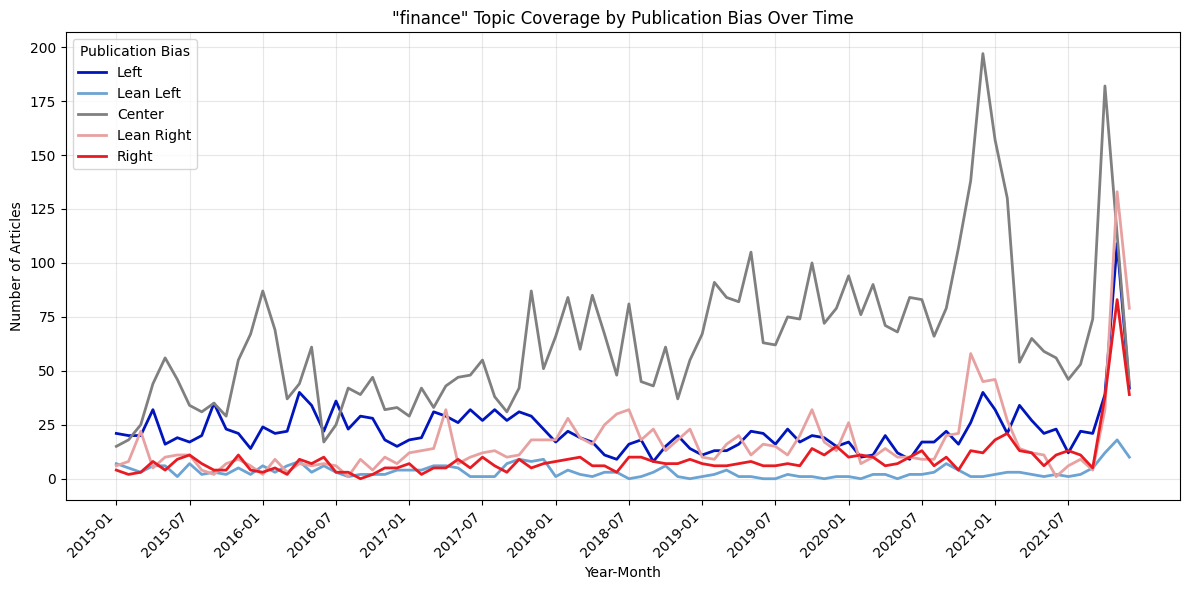

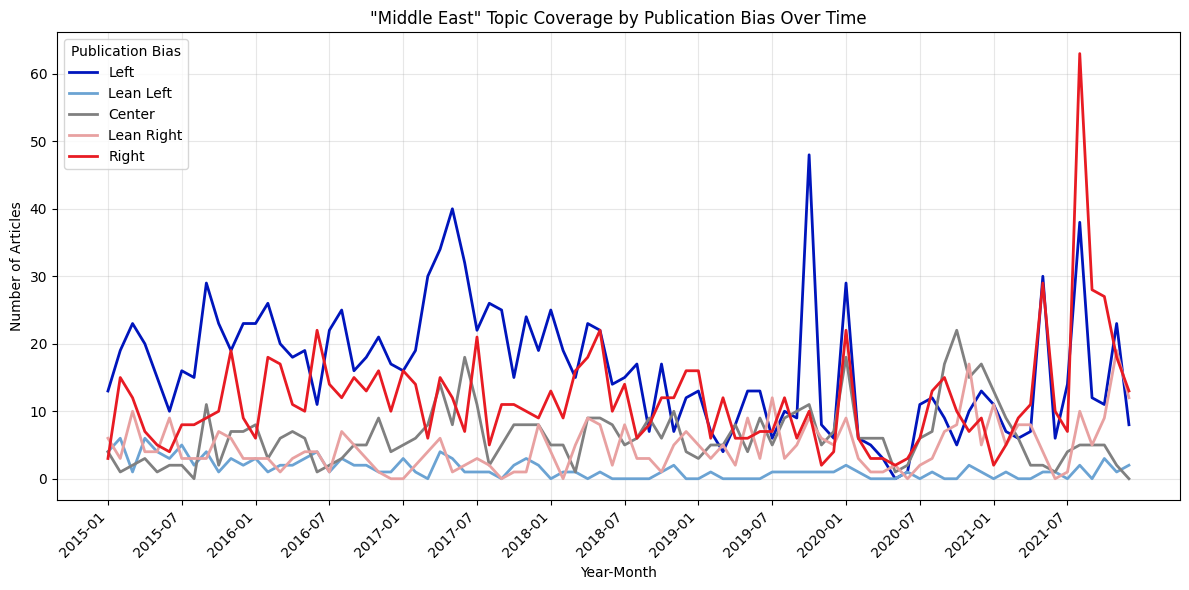

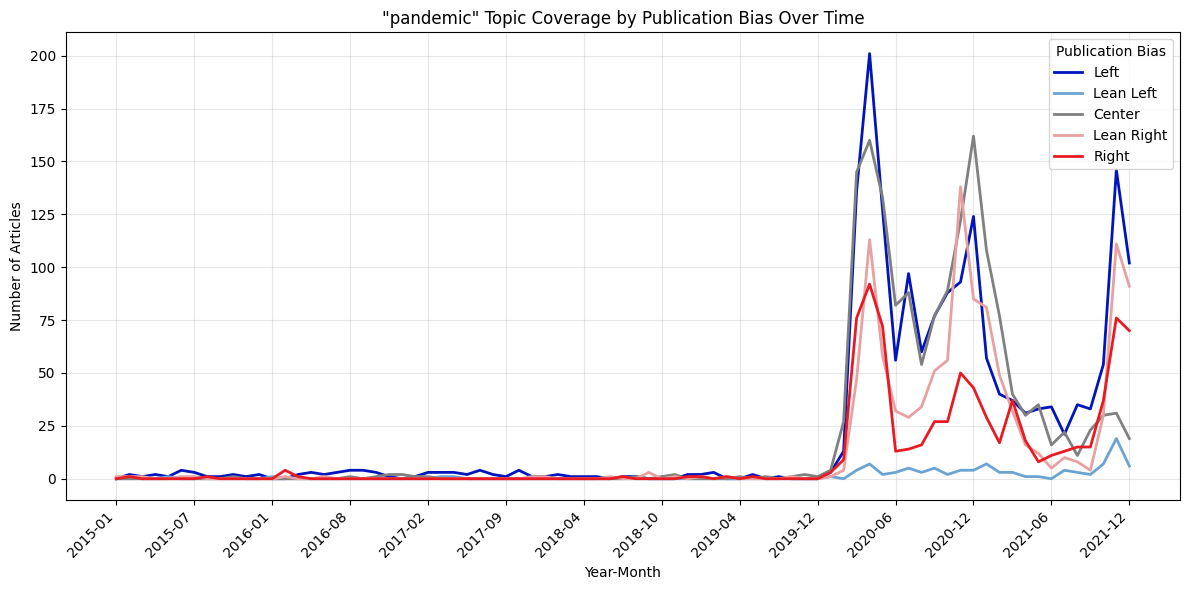

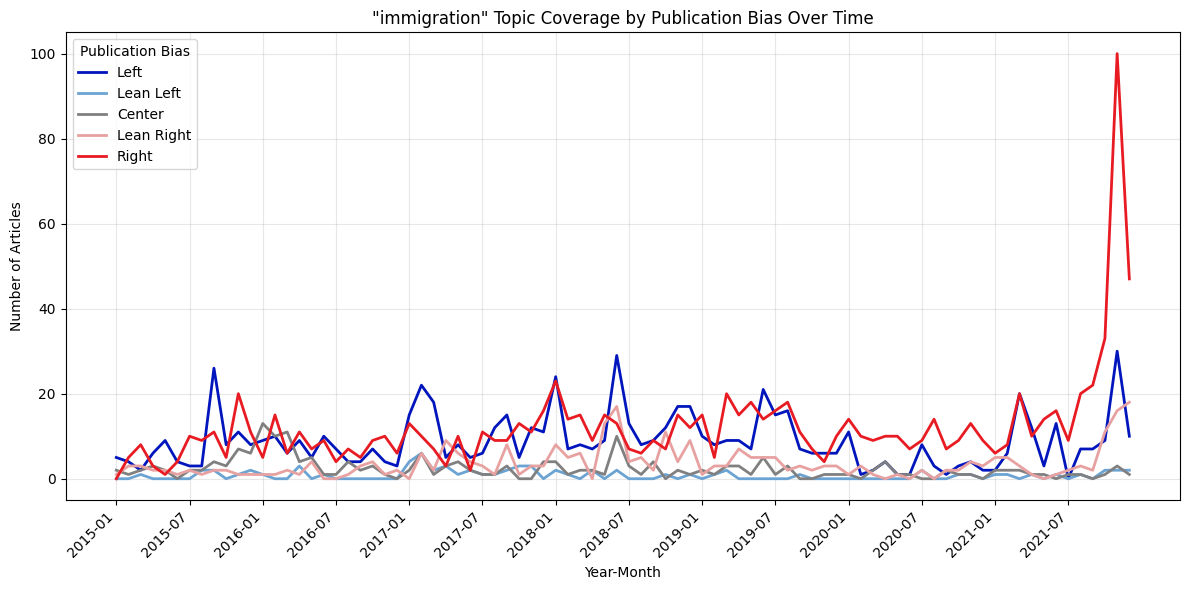

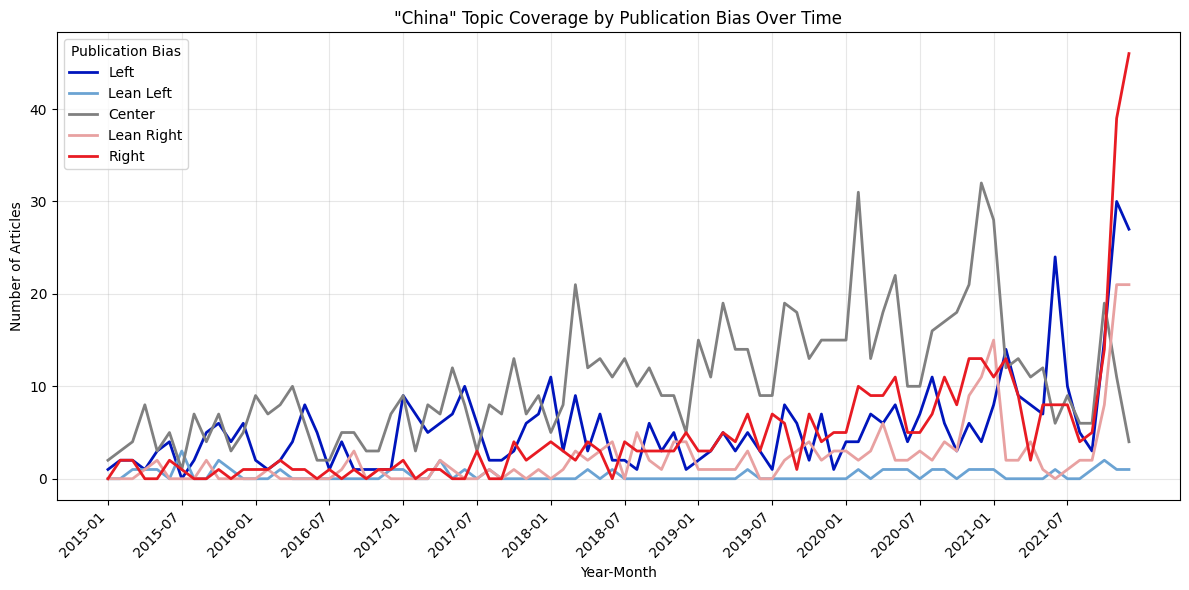

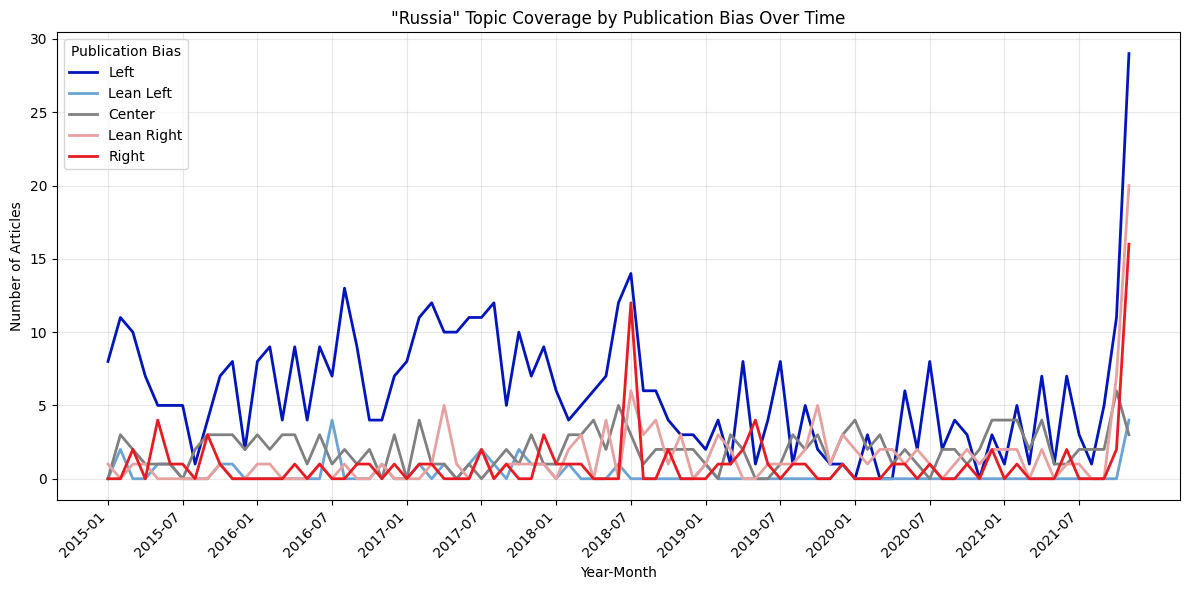

In [83]:
# Loop through topics, produce simple viz

for topic in topic_list:

    # Get counts by bias and time
    topic_df = full_df[full_df['topic_top1'] == topic]
    topic_counts = topic_df.groupby(['year_month', 'bias']).size().unstack(fill_value=0)

    # Reorder columns
    topic_counts = topic_counts.reindex(columns=column_order, fill_value=0)
    topic_counts.index = topic_counts.index.astype(str)

    # Plot
    plt.figure(figsize=(12, 6))
    for bias in topic_counts.columns:
        plt.plot(topic_counts.index, topic_counts[bias], label=bias, color=color_map[bias], linewidth=2)

    plt.xlabel('Year-Month')
    plt.ylabel('Number of Articles')
    plt.title(f'"{topic}" Topic Coverage by Publication Bias Over Time')
    plt.legend(title='Publication Bias')
    plt.xticks(range(0, len(topic_counts), 6), topic_counts.index[::6], rotation=45, ha='right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

### Frame & Topic Co-Occurence

##### Frame-Frame Occurences

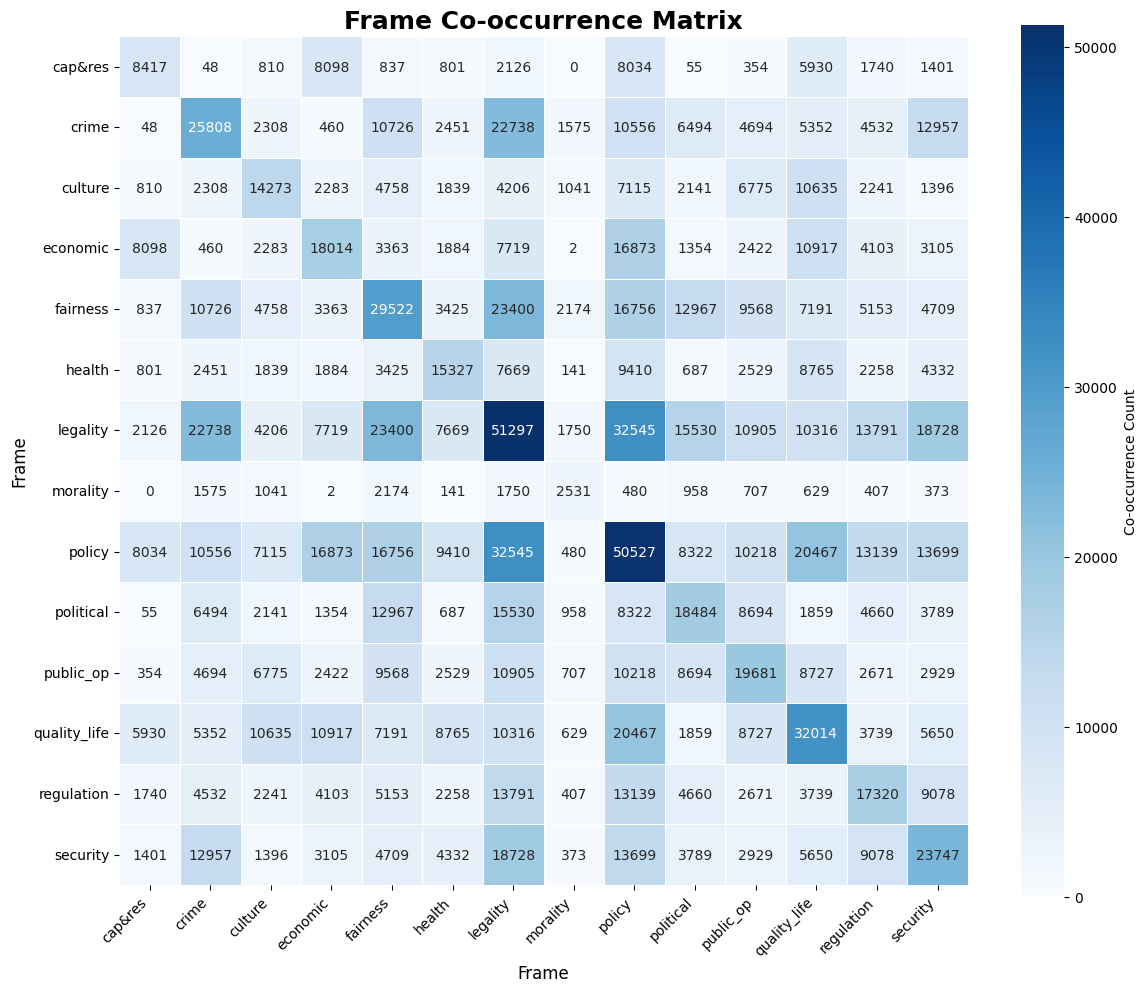

In [110]:
# Frame Co-Occurence & FrameTopic Co-Occurence Matrices

def create_frame_cooccur_matrix(df_subset, frame_names):
    n_frames = len(frame_names)
    co_occur_matrix = np.zeros((n_frames, n_frames))
    
    for idx, row in df_subset.iterrows():
        vector = row['vector']
        
        present_frames = [i for i, val in enumerate(vector) if val == 1]
        
        for i in present_frames:
            for j in present_frames:
                co_occur_matrix[i, j] += 1

    return pd.DataFrame(co_occur_matrix, index=frame_names, columns=frame_names)

co_occur_df = create_frame_cooccur_matrix(full_df, ordered_frame_names)

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(co_occur_df, annot=True, fmt='.0f', cmap='Blues', 
            cbar_kws={'label': 'Co-occurrence Count'}, 
            linewidths=0.5, square=True)
plt.xlabel('Frame', fontsize=12)
plt.ylabel('Frame', fontsize=12)
plt.title('Frame Co-occurrence Matrix', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

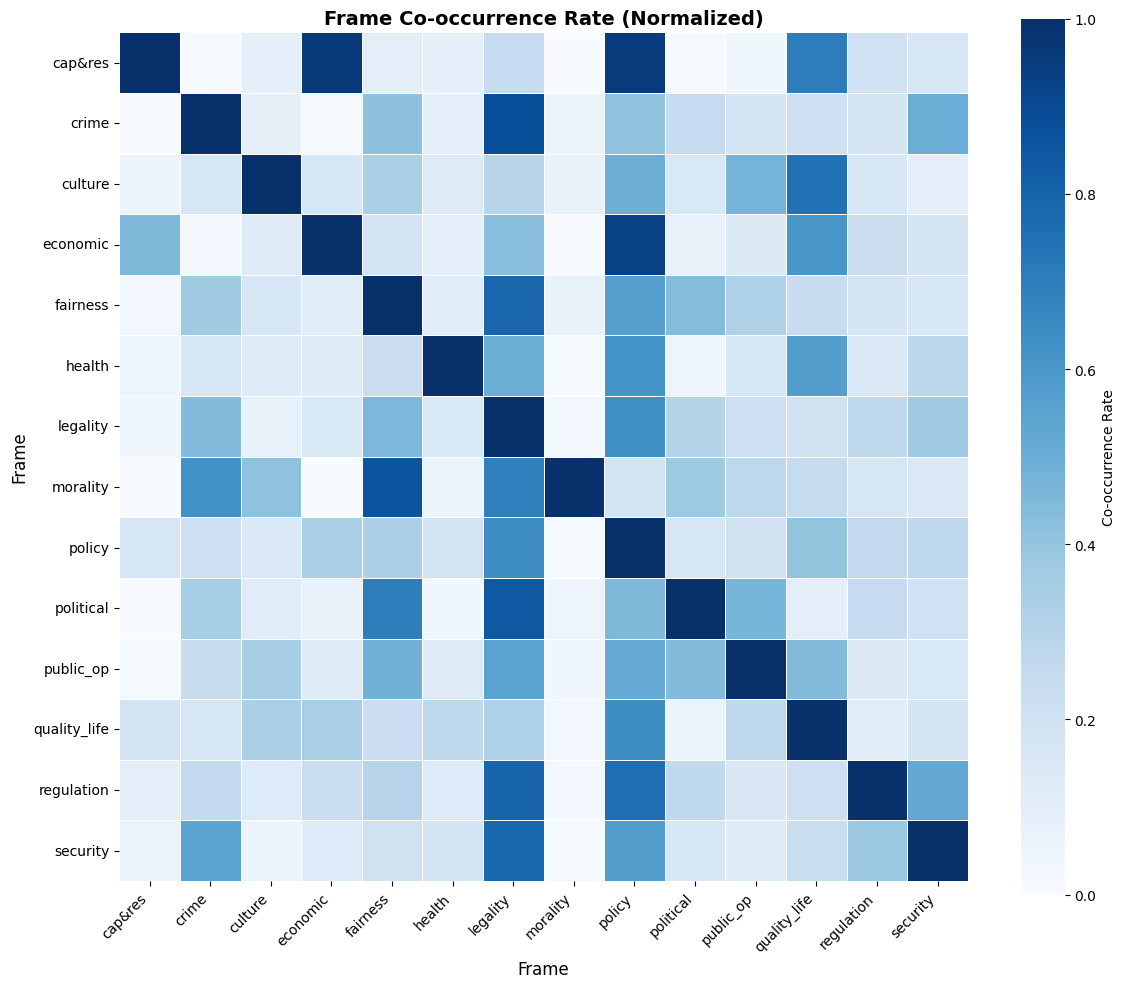

In [111]:
# Take co-occurence matrix and show normalized version
co_occur_normalized = co_occur_df.copy()

# Ensure no division by 0
for i in range(n_frames):
    if co_occur_df.iloc[i, i] > 0: 
        co_occur_normalized.iloc[i, :] = co_occur_df.iloc[i, :] / co_occur_df.iloc[i, i]

plt.figure(figsize=(12, 10))
sns.heatmap(co_occur_normalized, annot=False, fmt='.2f', cmap='Blues',
            vmin=0, vmax=1, cbar_kws={'label': 'Co-occurrence Rate'}, 
            linewidths=0.5, square=True)
plt.xlabel('Frame', fontsize=12)
plt.ylabel('Frame', fontsize=12)
plt.title('Frame Co-occurrence Rate (Normalized)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

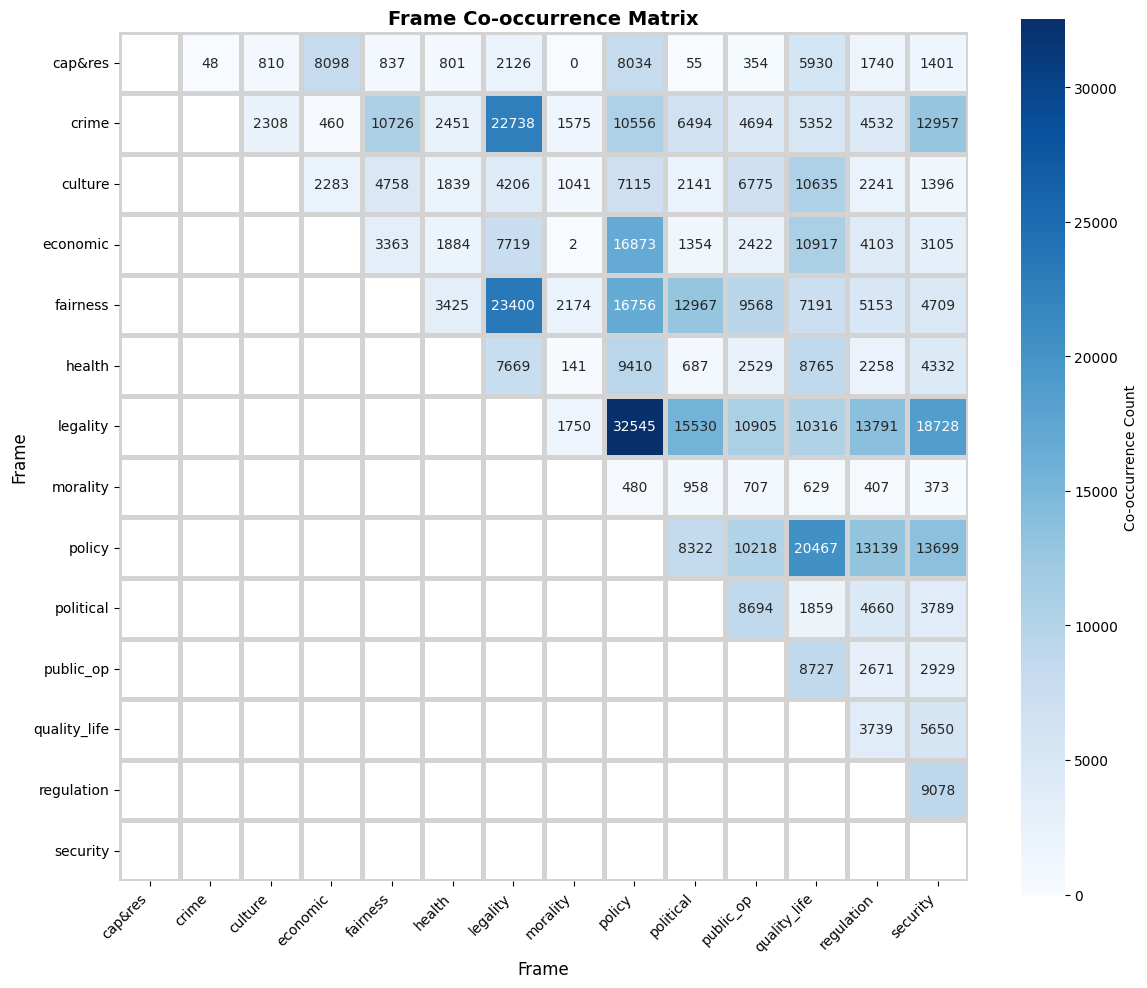

In [112]:
mask = np.tril(np.ones_like(co_occur_df, dtype=bool), k=0)

plt.figure(figsize=(12, 10))
sns.heatmap(co_occur_df, mask=mask, annot=True, fmt='.0f', cmap='Blues', 
            cbar_kws={'label': 'Co-occurrence Count'}, 
            linewidths=2.5, linecolor='lightgrey', square=True)
plt.xlabel('Frame', fontsize=12)
plt.ylabel('Frame', fontsize=12)
plt.title('Frame Co-occurrence Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

##### Topic-Frame Matrices

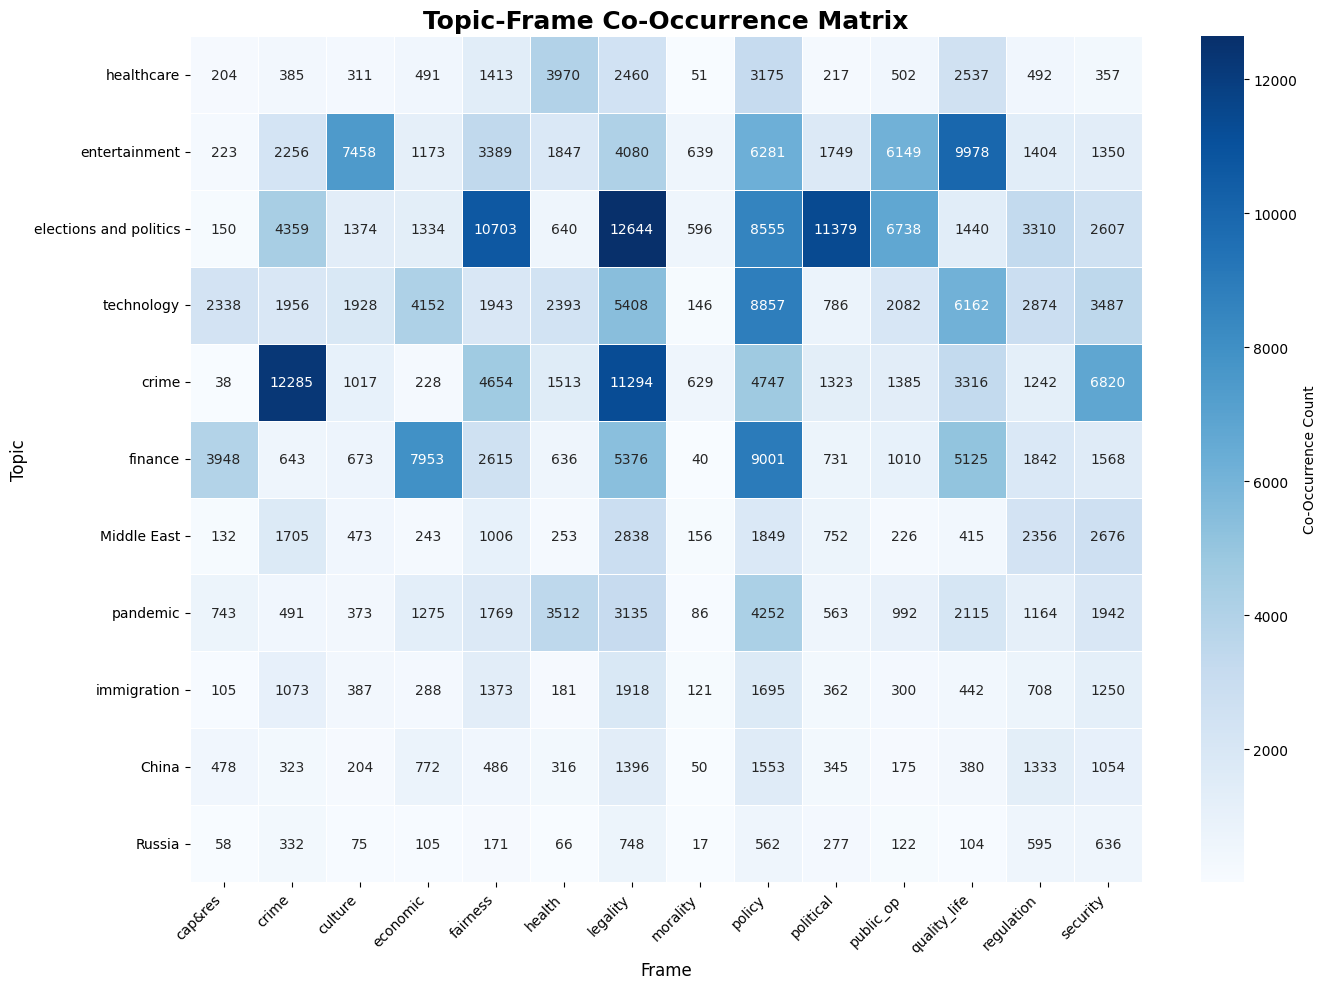

In [98]:
def create_topic_frame_matrix(df_subset, topic_list, frame_names):
    """Create topic-frame co-occurrence matrix for a given dataframe subset"""
    n_topics = len(topic_list)
    n_frames = len(frame_names)
    topic_frame_matrix = np.zeros((n_topics, n_frames))
    
    for idx, row in df_subset.iterrows():
        topic = row['topic_top1']
        vector = row['vector']
        
        # Convert to list if numpy array
        if isinstance(vector, np.ndarray):
            vector = vector.tolist()
        
        # Get topic index
        topic_idx = np.where(topic_list == topic)[0][0]
        
        # Count frame occurrences for this topic
        for frame_idx, val in enumerate(vector):
            if val == 1:
                topic_frame_matrix[topic_idx, frame_idx] += 1
    
    return pd.DataFrame(topic_frame_matrix, index=topic_list, columns=frame_names)

topic_frame_df = create_topic_frame_matrix(full_df, topic_list, ordered_frame_names)

plt.figure(figsize=(14, 10))
sns.heatmap(topic_frame_df, annot=True, fmt='.0f', cmap='Blues',
            cbar_kws={'label': 'Co-Occurrence Count'},
            linewidths=0.5)
plt.xlabel('Frame', fontsize=12)
plt.ylabel('Topic', fontsize=12)
plt.title('Topic-Frame Co-Occurrence Matrix', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Topic-Frame Co-Occurence by Bias

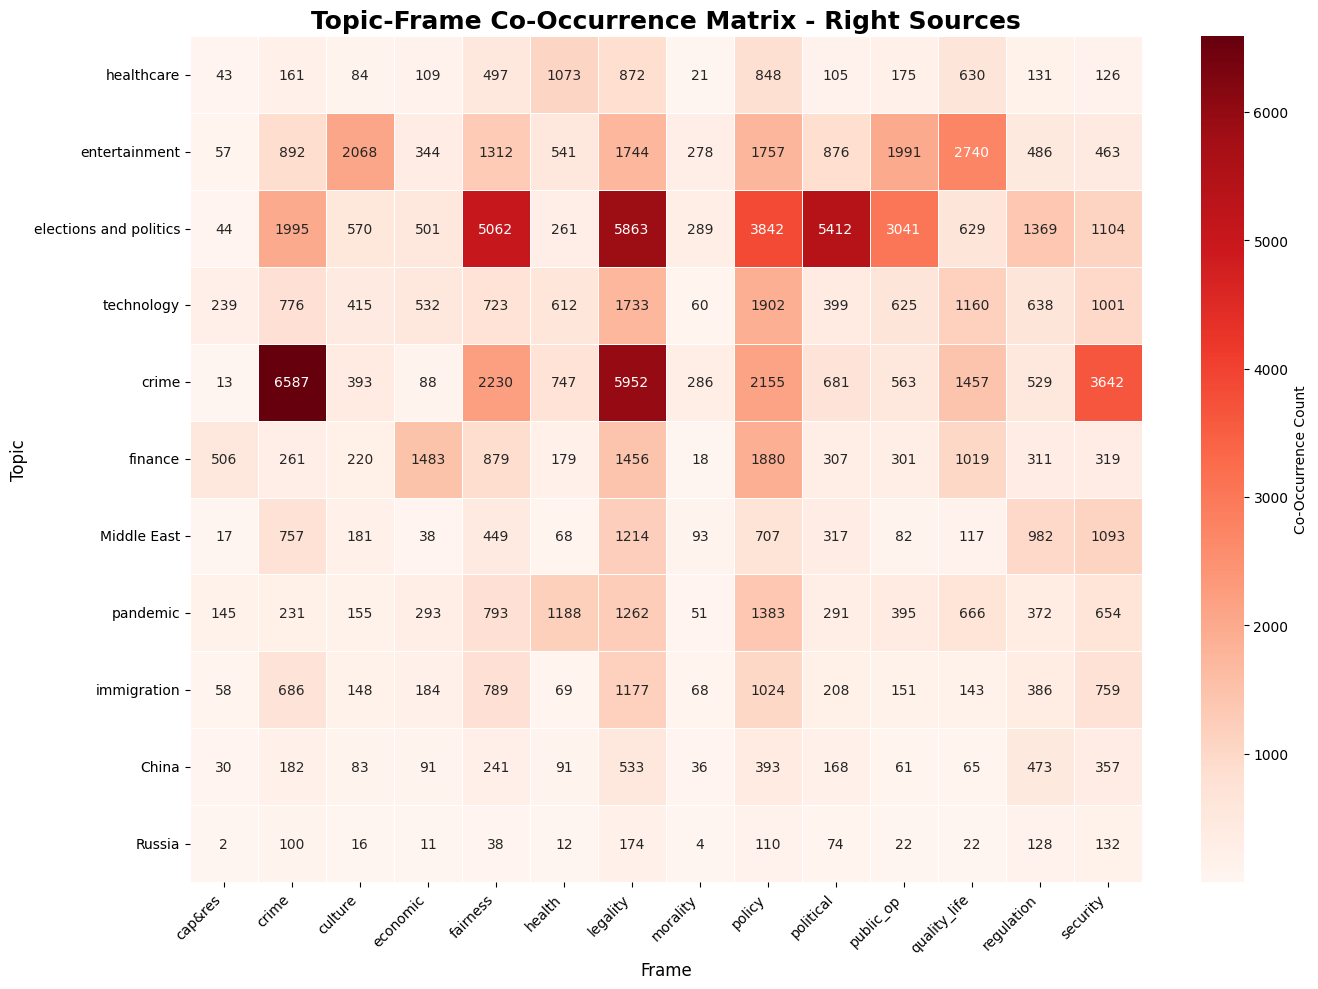

In [ ]:
# Right topic-frame co-occurence matrix
right_topic_frame_df = create_topic_frame_matrix(right_df, topic_list, ordered_frame_names)

plt.figure(figsize=(14,10))
sns.heatmap(right_topic_frame_df, annot=True, fmt='.0f', cmap='Reds',
            cbar_kws={'label': 'Co-Occurrence Count'},
            linewidths=0.5)
plt.xlabel('Frame', fontsize=12)
plt.ylabel('Topic', fontsize=12)
plt.title('Topic-Frame Co-Occurrence Matrix - Right Sources', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

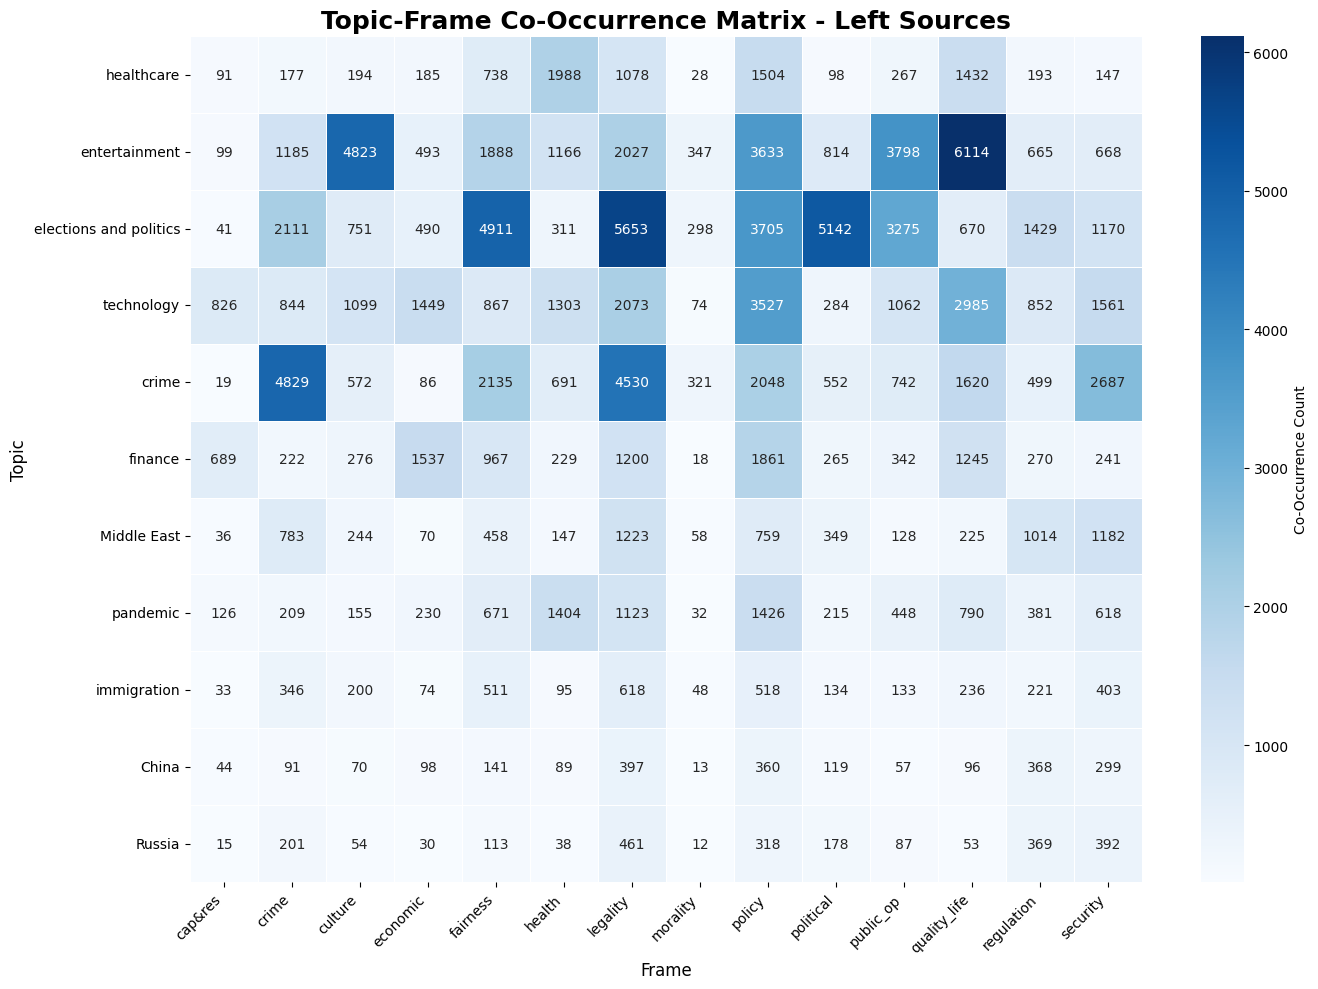

In [100]:
# Left topic-frame co-occurence matrix
left_topic_frame_df = create_topic_frame_matrix(left_df, topic_list, ordered_frame_names)

plt.figure(figsize=(14, 10))
sns.heatmap(left_topic_frame_df, annot=True, fmt='.0f', cmap='Blues',
            cbar_kws={'label': 'Co-Occurrence Count'},
            linewidths=0.5)
plt.xlabel('Frame', fontsize=12)
plt.ylabel('Topic', fontsize=12)
plt.title('Topic-Frame Co-Occurrence Matrix - Left Sources', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


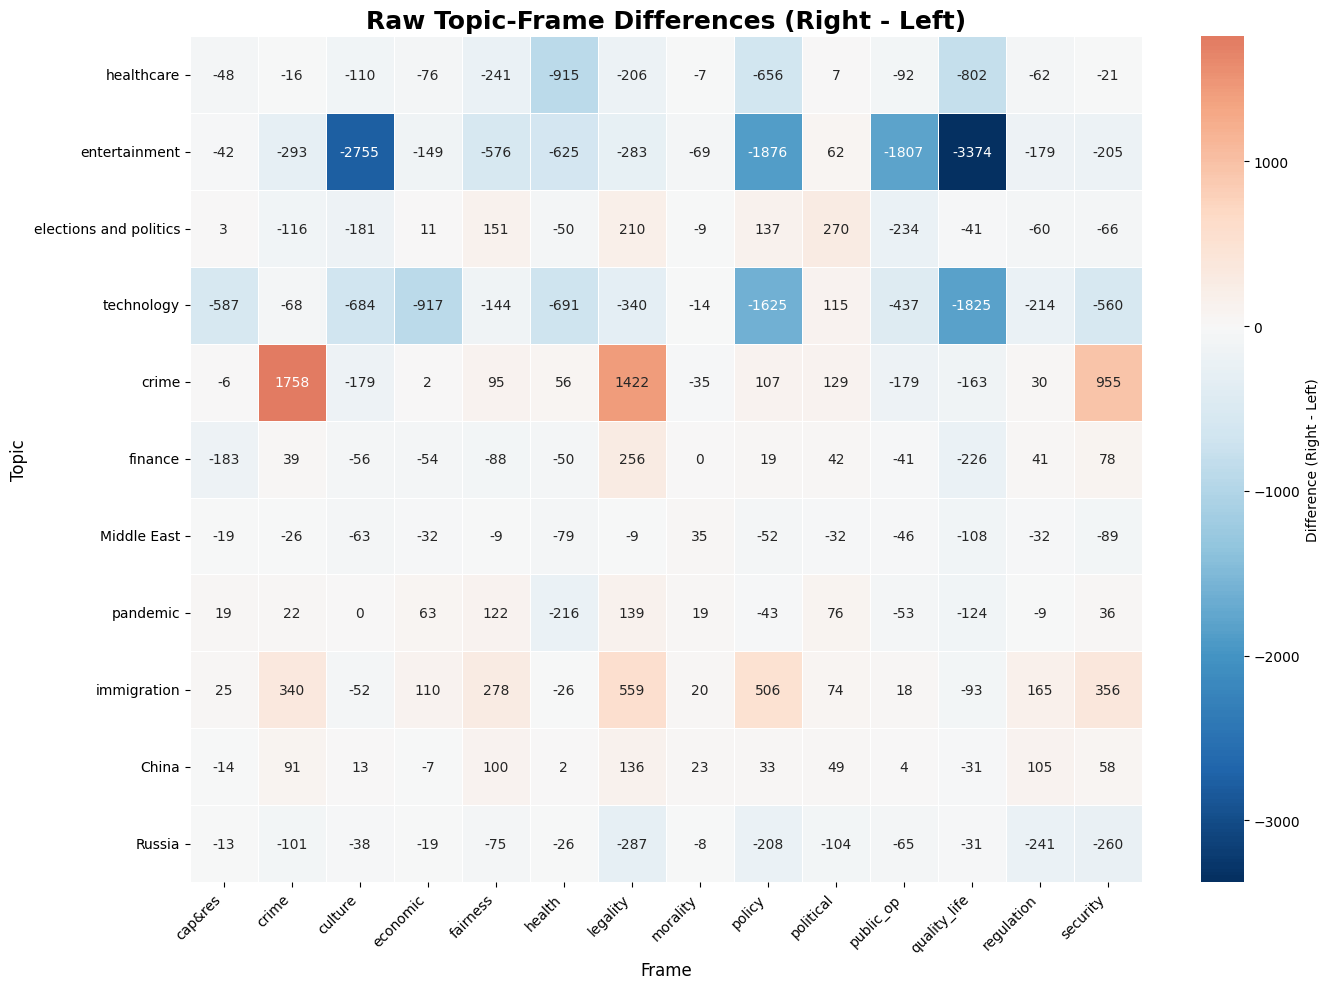

In [105]:
# DIFFERENCE BETWEEN THE TWO - AND SHADE RED/BLUE BASED ON WHICH IS HIGHER
diff_topic_frame_df = right_topic_frame_df - left_topic_frame_df

plt.figure(figsize=(14, 10))
sns.heatmap(diff_topic_frame_df, annot=True, fmt='.0f', cmap='RdBu_r',
            center=0, cbar_kws={'label': 'Difference (Right - Left)'},
            linewidths=0.5)
plt.xlabel('Frame', fontsize=12)
plt.ylabel('Topic', fontsize=12)
plt.title('Raw Topic-Frame Differences (Right - Left)', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

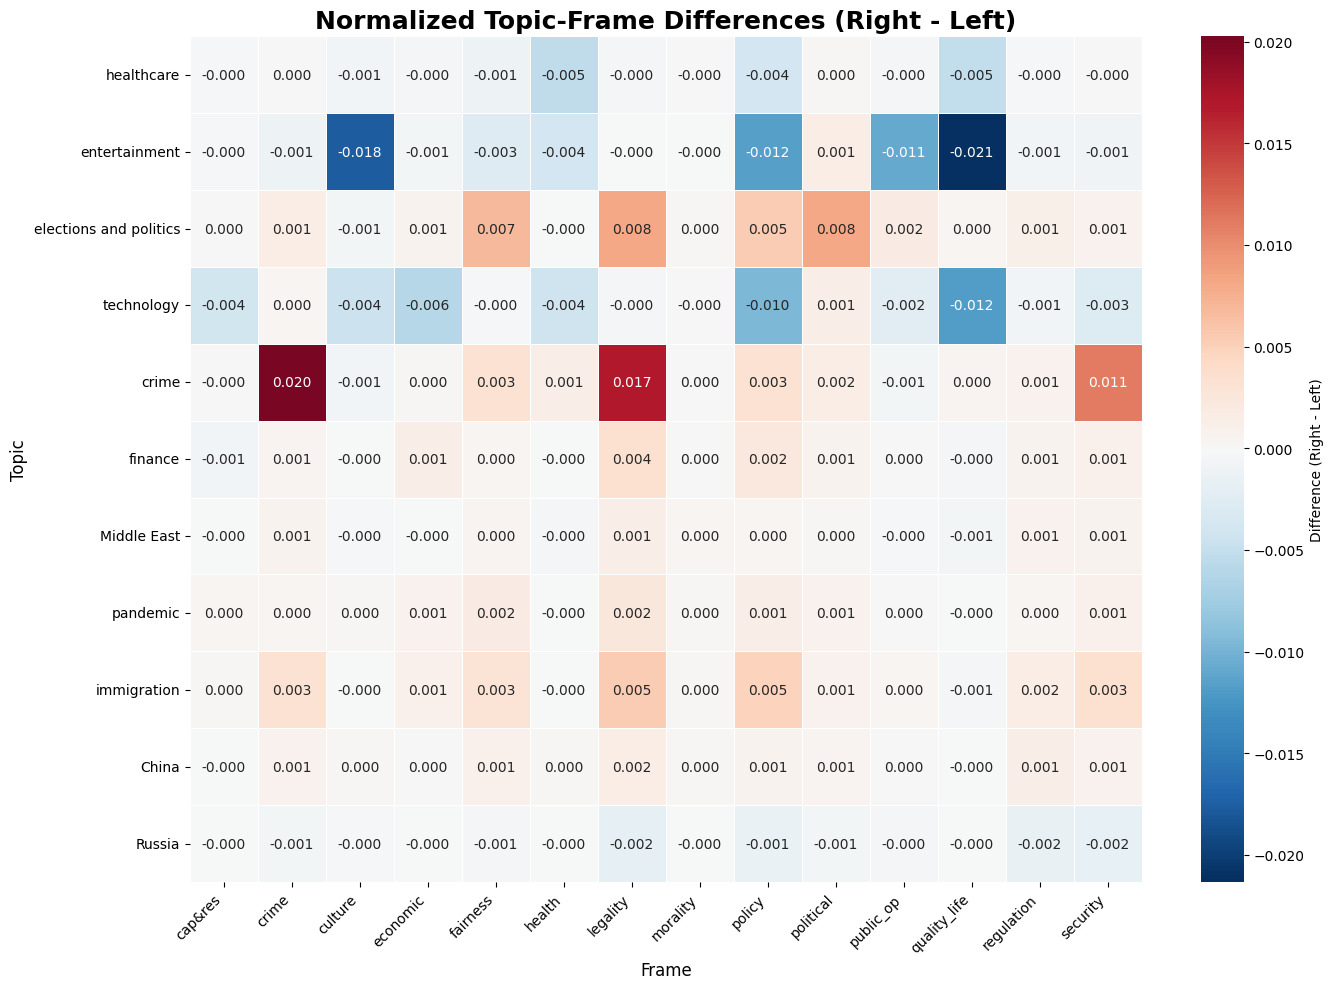

In [109]:
# Normalized differences between right/left topic-frame co-occurence matrices
right_total = right_topic_frame_df.values.sum()
left_total = left_topic_frame_df.values.sum()
diff_normalized_df = (right_topic_frame_df / right_total) - (left_topic_frame_df / left_total)

plt.figure(figsize=(14, 10))
sns.heatmap(diff_normalized_df, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, cbar_kws={'label': 'Difference (Right - Left)'},
            linewidths=0.5)
plt.xlabel('Frame', fontsize=12)
plt.ylabel('Topic', fontsize=12)
plt.title('Normalized Topic-Frame Differences (Right - Left)', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()